In [91]:
# Firstly import all required packages
# enable interactive mode of matplotlib
%matplotlib notebook

# import cv2  # python OpenCV
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (6,5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns
plt.style.use('seaborn')
import time
import pickle  # package for dump & load data
import warnings

Description of `tips` dataset.

Food servers’ tips in restaurants may be influenced by many factors, including the nature of the restaurant, size of the party, and table locations in the restaurant. Restaurant managers need to know which factors matter when they assign tables to food servers. For the sake of staff morale, they usually want to avoid either the substance or the appearance of unfair treatment of the servers, for whom tips (at least in restaurants in the United States) are a major component of pay. In one restaurant, a food server recorded the following data on all cus- tomers they served during an interval of two and a half months in early 1990. The restaurant, located in a suburban shopping mall, was part of a national chain and served a varied menu. In observance of local law, the restaurant offered to seat in a non-smoking section to patrons who requested it. Each record includes a day and time, and taken together, they show the server’s work schedule.

In [15]:
# use another dataset from seaborn docs for checking boxplot
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [16]:
tips['smoker'].replace({'Yes': True, 'No': False}, inplace=True)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,False,Sun,Dinner,2
1,10.34,1.66,Male,False,Sun,Dinner,3
2,21.01,3.50,Male,False,Sun,Dinner,3
3,23.68,3.31,Male,False,Sun,Dinner,2
4,24.59,3.61,Female,False,Sun,Dinner,4


# ДЗ

Для датасета `tips` необходимо ответить на следующие вопросы:
* Сколько мужчин и сколько женщин заплатили чаевые?
* Определите долю курящих среди мужчин и женщин.
* На какой день в среднем приходилось наибольшее количество посетителей? (учитывайте размер столика)
* На какое время суток приходится наибольшее количество чаевых?
* В какой день недели был заказ с максимальным счетом?
* Постройте столбчатую гистограмму, где данные сгруппированы по дню недели (X) и медианное значение общего счета (Y). Столбцы для каждого дня должны учитывать, курит посетитель или нет.

#### Сколько мужчин и сколько женщин заплатили чаевые?

Для этого нужно воспользоваться срезом по столбцу и посчитать через функцию `value_counts()`

In [6]:
tips['sex'].value_counts()

Male      157
Female     87
Name: sex, dtype: int64

#### Определите долю курящих среди мужчин и женщин. 

In [47]:
# using indexing
print('Man smoke -> {:.1f} %'.format( tips[(tips['sex']=='Male') & (tips['smoker']==True)].shape[0] / 
                                      tips[tips['sex']=='Male'].shape[0] * 100))

print('Woman smoke -> {:.1f} %'.format( tips[(tips['sex']=='Female') & (tips['smoker']==True)].shape[0] / 
                                        tips[tips['sex']=='Female'].shape[0] * 100))

Man smoke -> 38.2 %
Woman smoke -> 37.9 %


#### На какой день в среднем приходилось наибольшее количество посетителей? (учитывайте размер столика)

Это задача на метод `groupby`. Сначала необходимо сгруппировать данные по дням и посчитать сумму посетителей *size* для каждого дня. Остаётся определить индекс того, в каком дне максимум - поможет встроенная функция `idxmax`.

In [57]:
# See just as example value counts 
tips['day'].value_counts()

Sat     87
Sun     76
Thur    62
Fri     19
Name: day, dtype: int64

In [88]:
tips.groupby('day').mean()['size'].idxmax()

'Sun'

#### На какое время суток приходится наибольшее количество чаевых?

Полностью аналогичная задача предыдущей.

In [59]:
tips.groupby('time').sum()['tip'].idxmax()

'Dinner'

#### В какой день недели был заказ с максимальным счетом?

Найдем индекс в таблице заказа с максимальным счетом с помощью функции `idxmax`.
А затем для этой строки получим день недели.

In [79]:
tips.iloc[tips['tip'].idxmax()]

total_bill     50.81
tip               10
sex             Male
smoker          True
day              Sat
time          Dinner
size               3
Name: 170, dtype: object

In [80]:
tips.iloc[tips['tip'].idxmax()]['day']

'Sat'

#### Постройте столбчатую гистограмму, где данные сгруппированы по дню недели (X) и медианное значение общего счета (Y). Столбцы для каждого дня должны учитывать, курит посетитель или нет.

<IPython.core.display.Javascript object>


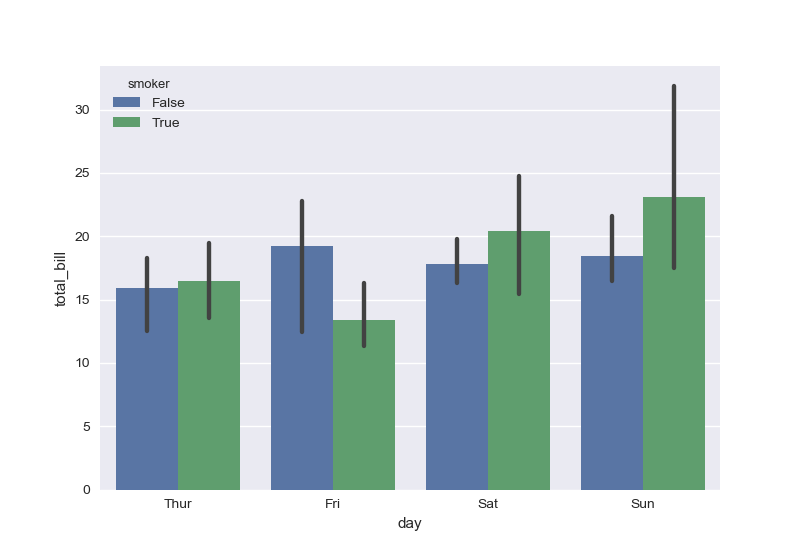

In [93]:
plt.figure()
sns.barplot(x="day", y="total_bill", hue="smoker", data=tips, estimator=np.median)